## Access to DP2

- author : Sylvie Dagoret-Campagne
- creation date : 2026-03-07

## Imports

In [1]:
import lsst.pipe.base

print(lsst.pipe.base.__version__)

g6f1feb8048+ea09edc8e9


In [2]:
import sys
import matplotlib.pyplot as plt
import lsst.afw.display as afwDisplay
from lsst.geom import SpherePoint, degrees
from lsst.afw.image import ExposureF
from lsst.skymap import PatchInfo, Index2D
import numpy as np
import pandas as pd
from astropy.time import Time
# %matplotlib widget
import seaborn as sns

In [3]:
# Define butler
from lsst.daf.butler import Butler

In [4]:
def get_uris_from_butler(butler, datasetType, collections=None, **query_kwargs):
    """
    Return a list of URIs for a given datasetType in a Butler collection.

    Parameters
    ----------
    butler : lsst.daf.butler.Butler
        The Butler object
    datasetType : str
        The dataset type, e.g. 'raw', 'calexp'
    collections : list of str, optional
        Butler collections to query
    query_kwargs : dict
        Additional query parameters, e.g. visit=123, filter='r'

    Returns
    -------
    uris : list of str
        File paths of the datasets
    """
    refs = butler.registry.queryDatasets(datasetType, collections=collections, **query_kwargs)
    return [butler.getURI(ref) for ref in refs]

In [5]:
def get_refs_from_butler(butler, datasetType, collections=None, **query_kwargs):
    """
    Return a list of Butler DatasetRef objects for a given datasetType in a Butler collection.

    Parameters
    ----------
    butler : lsst.daf.butler.Butler
        The Butler object
    datasetType : str
        The dataset type, e.g. 'raw', 'calexp'
    collections : list of str, optional
        Butler collections to query
    query_kwargs : dict
        Additional query parameters, e.g. visit=123, filter='r'

    Returns
    -------
    refs : list of DatasetRef
        Butler dataset references
    """
    refs = butler.registry.queryDatasets(datasetType, collections=collections, **query_kwargs)
    return refs

In [51]:
def get_refs_from_butler(
    butler,
    datasetType,
    collections=None,
    return_uris=False,
    **query_kwargs
):
    """
    Get dataset references (or URIs) from a Butler, safely handling numpy types.

    Parameters
    ----------
    butler : lsst.daf.butler.Butler
        Butler instance.
    datasetType : str
        Dataset type to query (e.g., "calexp", "raw", "src").
    collections : str or list of str, optional
        Butler collections to query.
    return_uris : bool, default False
        If True, return URIs instead of refs.
    **query_kwargs :
        Query parameters, e.g., visit=[...], ccd=[...], filter=['r','g'].

    Returns
    -------
    list of DatasetRef or list of str
        List of references or URIs.
    """

    # Convert numpy types to Python native types
    safe_kwargs = {}
    for k, v in query_kwargs.items():
        if isinstance(v, np.ndarray):
            safe_kwargs[k] = [int(x) if np.issubdtype(type(x), np.integer) else x for x in v]
        elif isinstance(v, (np.integer, np.int64, np.int32)):
            safe_kwargs[k] = int(v)
        else:
            safe_kwargs[k] = v

    # Query dataset references
    refs = butler.registry.queryDatasets(
        datasetType,
        collections=collections,
        **safe_kwargs
    )

    if return_uris:
        return [butler.getURI(ref) for ref in refs]

    return refs

## Configuration

- See collection here : https://usdf-rsp.slac.stanford.edu/plot-navigator
- See Campaign : https://rubinobs.atlassian.net/wiki/spaces/DM/pages/661192727/LSSTCam+Intermittent+DRP+Runs

In [6]:
REPO = 'dp2_prep'
#collection = 'LSSTCam/runs/DRP/v30_0_1/DM-54061'
collection =  'LSSTCam/runs/DRP/v30_0_4/DM-54249'
#collection =  'LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881'
skymapName = "lsst_cells_v2"
instrument = "LSSTCam"
date_start = 20260101
date_selection = 20260310
where_clause = "instrument = '" + f"{instrument}" + "'"
where_clause_date = where_clause + f"and day_obs >= {date_start}"
butler = Butler(REPO, collections=collection)
registry = butler.registry

In [7]:
try:
    skymap = butler.get("skyMap", skymap=skymapName, collections=collection)
except Exception as inst:
    print(type(inst))  # the exception type
    print(inst.args)  # arguments stored in .args
    print(inst)  # __str__ allows args to be printed directly,

In [8]:
skymap

In [9]:
df_exposure = pd.DataFrame(
    {
        "id": pd.Series(dtype="int"),
        "obs_id": pd.Series(dtype="int"),
        "day_obs": pd.Series(dtype="int"),
        "seq_num": pd.Series(dtype="int"),
        "time_start": pd.Series(dtype="str"),  # ou 'datetime64[ns]' si c’est un datetime
        "time_end": pd.Series(dtype="str"),  # idem
        "type": pd.Series(dtype="str"),
        "target": pd.Series(dtype="str"),
        "filter": pd.Series(dtype="str"),
        "zenith_angle": pd.Series(dtype="float"),
        "expos": pd.Series(dtype="float"),  # ou 'int' selon le cas
        "ra": pd.Series(dtype="float"),
        "dec": pd.Series(dtype="float"),
        "skyangle": pd.Series(dtype="float"),
        "azimuth": pd.Series(dtype="float"),
        "zenith": pd.Series(dtype="float"),
        "science_program": pd.Series(dtype="str"),
        "jd": pd.Series(dtype="float"),
        "mjd": pd.Series(dtype="float"),
    }
)

In [10]:
# save the data array in rows before saving in pandas dataframe
rows = []
for count, info in enumerate(registry.queryDimensionRecords("exposure", where=where_clause_date)):
    try:
        jd_start = info.timespan.begin.value
        jd_end = info.timespan.end.value
        the_Time_start = Time(jd_start, format="jd", scale="utc")
        the_Time_end = Time(jd_end, format="jd", scale="utc")
        mjd_start = the_Time_start.mjd
        mjd_end = the_Time_end.mjd
        isot_start = the_Time_start.isot
        isot_end = the_Time_end.isot

        if count == 0:
            print("===== Time Conversion Debug Info =====")
            print(f"JD start      : {jd_start} (type: {type(jd_start)})")
            print(f"JD end        : {jd_end} (type: {type(jd_end)})")
            print(f"MJD start     : {mjd_start} (type: {type(mjd_start)})")
            print(f"MJD end       : {mjd_end} (type: {type(mjd_end)})")
            print(f"ISOT start    : {isot_start} (type: {type(isot_start)})")
            print(f"ISOT end      : {isot_end} (type: {type(isot_end)})")
            print("=======================================")

        # put row in a dictionnary before stacking
        row = {
            "id": info.id,
            "obs_id": info.obs_id,
            "day_obs": info.day_obs,
            "seq_num": info.seq_num,
            "time_start": isot_start,
            "time_end": isot_end,
            "type": info.observation_type,
            "target": info.target_name,
            "filter": info.physical_filter,
            "zenith_angle": info.zenith_angle,
            "expos": info.exposure_time,  # Exemple : adapter selon ton objet
            "ra": info.tracking_ra,
            "dec": info.tracking_dec,
            "skyangle": info.sky_angle,
            "azimuth": info.azimuth,
            "zenith": info.zenith_angle,
            "science_program": info.science_program,
            "jd": float(jd_start),
            "mjd": float(mjd_start),
        }
        rows.append(row)
        if count>50000:
            break

    except ValueError as e:
        print(f"Erreur de valeur : {e}")
    except FileNotFoundError as e:
        print(f"Fichier introuvable : {e}")
    except Exception as e:
        print(f"Erreur inattendue : {type(e).__name__} - {e}")
        print(f">>>   Unexpected error at row {count}:", sys.exc_info()[0])
        traceback.print_exc()  # affiche la stack trace complète

===== Time Conversion Debug Info =====
JD start      : 2461042.6155619714 (type: <class 'numpy.float64'>)
JD end        : 2461042.6159199537 (type: <class 'numpy.float64'>)
MJD start     : 61042.11556197144 (type: <class 'numpy.float64'>)
MJD end       : 61042.11591995368 (type: <class 'numpy.float64'>)
ISOT start    : 2026-01-02T02:46:24.554 (type: <class 'str'>)
ISOT end      : 2026-01-02T02:46:55.484 (type: <class 'str'>)


In [11]:
df_exposure = pd.DataFrame(rows)

In [12]:
df_science = df_exposure[df_exposure.type == "science"]
df_science.reset_index(drop=True, inplace=True)

In [13]:
df_science.target.unique()

array(['lowdust', 'LMC_SMC, euclid_overlap', 'euclid_overlap', 'LMC_SMC',
       'ddf_elaiss1, lowdust', 'lowdust, ddf_xmm_lss',
       'lowdust, ddf_ecdfs', 'lowdust, ddf_edfs_a', 'ddf_edfs_b, lowdust',
       'LMC_SMC, lowdust', 'scp, euclid_overlap', 'LMC_SMC, scp',
       'lowdust, ddf_cosmos', 'lowdust, scp', 'dusty_plane, lowdust',
       'dusty_plane', 'scp', 'dusty_plane, scp', 'bulgy',
       'dusty_plane, bulgy', 'lowdust, nes', 'lowdust, bulgy',
       'LMC_SMC, scp, euclid_overlap', 'scp, lowdust', 'scp, LMC_SMC',
       'bulgy, dusty_plane', 'ddf_xmm_lss, lowdust', 'ddf_ecdfs, lowdust',
       'ddf_edfs_a, lowdust', 'lowdust, LMC_SMC', 'nes, lowdust',
       'bulgy, lowdust', 'nes, dusty_plane', 'euclid_overlap, scp',
       'euclid_overlap, LMC_SMC', 'scp, lowdust, LMC_SMC', 'nes',
       'bulgy, nes', 'scp, dusty_plane', 'nes, dusty_plane, lowdust',
       'ddf_cosmos, lowdust'], dtype=object)

In [14]:
def get_tract_patch(row, skymap):
    if pd.isna(row['ra']) or pd.isna(row['dec']):
        return pd.Series({"tract": None, "patch": None})
    
    target_point = SpherePoint(row['ra'], row['dec'], degrees)

    tract_info = skymap.findTract(target_point)
    patch_info = tract_info.findPatch(target_point)
    tractNbSel = tract_info.getId()
    patchNbSel =  patch_info.getSequentialIndex()
    patch_index_str = f"{patch_info.getIndex()[0]},{patch_info.getIndex()[1]}"
   
    
    return pd.Series({"tract":   tractNbSel, "patch":  patchNbSel, "patch_str": patch_index_str})


In [15]:
df=df_science.copy()
df["band"] = df["filter"].apply(lambda x : x.split("_")[0])

In [16]:
df[['tract', 'patch', "patch_str"]] = df.apply(get_tract_patch, axis=1, args=(skymap,))

In [17]:
df

,id,obs_id,day_obs,seq_num,time_start,time_end,type,target,filter,zenith_angle,...,skyangle,azimuth,zenith,science_program,jd,mjd,band,tract,patch,patch_str
0,2026010100064,MC_O_20260101_000064,20260101,64,2026-01-02T02:46:24.554,2026-01-02T02:46:55.484,science,lowdust,i_39,32.073217,...,338.559725,225.116062,32.073217,BLOCK-417,2.461043e+06,61042.115562,i,2384,24,"4,2"
1,2026010100142,MC_O_20260101_000142,20260101,142,2026-01-02T03:38:24.359,2026-01-02T03:38:55.294,science,"LMC_SMC, euclid_overlap",i_39,47.300498,...,298.383154,192.646327,47.300498,BLOCK-417,2.461043e+06,61042.151671,i,390,25,"5,2"
2,2026010100138,MC_O_20260101_000138,20260101,138,2026-01-02T03:35:48.472,2026-01-02T03:36:19.402,science,euclid_overlap,i_39,52.480633,...,319.978927,194.173529,52.480633,BLOCK-417,2.461043e+06,61042.149867,i,259,64,"4,6"
3,2026010100146,MC_O_20260101_000146,20260101,146,2026-01-02T03:41:02.788,2026-01-02T03:41:33.719,science,LMC_SMC,i_39,43.640155,...,299.888099,197.690125,43.640155,BLOCK-417,2.461043e+06,61042.153504,i,626,60,"0,6"
4,2026010100219,MC_O_20260101_000219,20260101,219,2026-01-02T04:31:30.366,2026-01-02T04:32:01.296,science,LMC_SMC,i_39,42.145491,...,284.850865,189.184279,42.145491,BLOCK-417,2.461043e+06,61042.188546,i,549,28,"8,2"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,2026010800500,MC_O_20260108_000500,20260108,500,2026-01-09T08:20:10.058,2026-01-09T08:20:40.988,science,"dusty_plane, lowdust",y_10,17.525190,...,307.017852,188.517915,17.525190,BLOCK-419,2.461050e+06,61049.347339,y,2605,13,"3,1"
2913,2026010800501,MC_O_20260108_000501,20260108,501,2026-01-09T08:20:54.098,2026-01-09T08:21:25.027,science,"bulgy, dusty_plane",y_10,22.146215,...,322.308403,195.185667,22.146215,BLOCK-419,2.461050e+06,61049.347848,y,2120,56,"6,5"
2914,2026010800504,MC_O_20260108_000504,20260108,504,2026-01-09T08:22:58.258,2026-01-09T08:23:29.189,science,"bulgy, dusty_plane",y_10,20.739668,...,311.615326,189.525808,20.739668,BLOCK-419,2.461050e+06,61049.349285,y,2278,6,"6,0"
2915,2026010800510,MC_O_20260108_000510,20260108,510,2026-01-09T08:27:06.455,2026-01-09T08:27:37.388,science,lowdust,y_10,17.876991,...,281.200568,167.497018,17.876991,BLOCK-419,2.461050e+06,61049.352158,y,2610,11,"1,1"


In [18]:
print(list(df.target.unique()))

['lowdust', 'LMC_SMC, euclid_overlap', 'euclid_overlap', 'LMC_SMC', 'ddf_elaiss1, lowdust', 'lowdust, ddf_xmm_lss', 'lowdust, ddf_ecdfs', 'lowdust, ddf_edfs_a', 'ddf_edfs_b, lowdust', 'LMC_SMC, lowdust', 'scp, euclid_overlap', 'LMC_SMC, scp', 'lowdust, ddf_cosmos', 'lowdust, scp', 'dusty_plane, lowdust', 'dusty_plane', 'scp', 'dusty_plane, scp', 'bulgy', 'dusty_plane, bulgy', 'lowdust, nes', 'lowdust, bulgy', 'LMC_SMC, scp, euclid_overlap', 'scp, lowdust', 'scp, LMC_SMC', 'bulgy, dusty_plane', 'ddf_xmm_lss, lowdust', 'ddf_ecdfs, lowdust', 'ddf_edfs_a, lowdust', 'lowdust, LMC_SMC', 'nes, lowdust', 'bulgy, lowdust', 'nes, dusty_plane', 'euclid_overlap, scp', 'euclid_overlap, LMC_SMC', 'scp, lowdust, LMC_SMC', 'nes', 'bulgy, nes', 'scp, dusty_plane', 'nes, dusty_plane, lowdust', 'ddf_cosmos, lowdust']


In [19]:
df_cosmos = df[ (df.target ==  'ddf_cosmos, lowdust') | (df.target ==  '9813_lowdust, ddf_cosmos') ]
df_elaiss1 = df[df.target ==  'ddf_elaiss1, lowdust' ]

In [20]:
df_cosmos

,id,obs_id,day_obs,seq_num,time_start,time_end,type,target,filter,zenith_angle,...,skyangle,azimuth,zenith,science_program,jd,mjd,band,tract,patch,patch_str
2828,2026010800438,MC_O_20260108_000438,20260108,438,2026-01-09T07:30:35.908,2026-01-09T07:31:06.839,science,"ddf_cosmos, lowdust",y_10,32.030737,...,131.113781,359.540882,32.030737,BLOCK-419,2.461050e+06,61049.312916,y,9813,36,"6,3"
2835,2026010800437,MC_O_20260108_000437,20260108,437,2026-01-09T07:29:53.732,2026-01-09T07:30:24.663,science,"ddf_cosmos, lowdust",y_10,32.245481,...,134.483092,0.731979,32.245481,BLOCK-419,2.461050e+06,61049.312427,y,9813,43,"3,4"
2841,2026010800439,MC_O_20260108_000439,20260108,439,2026-01-09T07:33:24.048,2026-01-09T07:33:54.981,science,"ddf_cosmos, lowdust",g_6,32.342811,...,51.547946,357.962082,32.342811,BLOCK-419,2.461050e+06,61049.314862,g,9813,57,"7,5"
2842,2026010800440,MC_O_20260108_000440,20260108,440,2026-01-09T07:33:58.494,2026-01-09T07:34:29.423,science,"ddf_cosmos, lowdust",g_6,32.347538,...,51.547877,357.693727,32.347538,BLOCK-419,2.461050e+06,61049.315260,g,9813,57,"7,5"
2843,2026010800441,MC_O_20260108_000441,20260108,441,2026-01-09T07:34:32.744,2026-01-09T07:35:03.674,science,"ddf_cosmos, lowdust",g_6,32.352817,...,51.548327,357.426617,32.352817,BLOCK-419,2.461050e+06,61049.315657,g,9813,57,"7,5"
2844,2026010800442,MC_O_20260108_000442,20260108,442,2026-01-09T07:35:07.208,2026-01-09T07:35:38.140,science,"ddf_cosmos, lowdust",g_6,32.358699,...,51.547454,357.158809,32.358699,BLOCK-419,2.461050e+06,61049.316056,g,9813,57,"7,5"
2845,2026010800443,MC_O_20260108_000443,20260108,443,2026-01-09T07:35:41.768,2026-01-09T07:36:12.698,science,"ddf_cosmos, lowdust",g_6,32.365206,...,51.547882,356.889151,32.365206,BLOCK-419,2.461050e+06,61049.316456,g,9813,57,"7,5"
2846,2026010800444,MC_O_20260108_000444,20260108,444,2026-01-09T07:36:24.641,2026-01-09T07:36:55.570,science,"ddf_cosmos, lowdust",g_6,32.076391,...,48.901186,357.349477,32.076391,BLOCK-419,2.461050e+06,61049.316952,g,9813,34,"4,3"
2847,2026010800445,MC_O_20260108_000445,20260108,445,2026-01-09T07:39:18.360,2026-01-09T07:39:49.292,science,"ddf_cosmos, lowdust",i_39,32.203878,...,144.291523,355.462758,32.203878,BLOCK-419,2.461050e+06,61049.318962,i,9813,36,"6,3"
2848,2026010800446,MC_O_20260108_000446,20260108,446,2026-01-09T07:39:52.533,2026-01-09T07:40:23.463,science,"ddf_cosmos, lowdust",i_39,32.213932,...,144.291802,355.196225,32.213932,BLOCK-419,2.461050e+06,61049.319358,i,9813,36,"6,3"


In [21]:
df_elaiss1 

,id,obs_id,day_obs,seq_num,time_start,time_end,type,target,filter,zenith_angle,...,skyangle,azimuth,zenith,science_program,jd,mjd,band,tract,patch,patch_str
17,2026010100036,MC_O_20260101_000036,20260101,36,2026-01-02T02:24:18.988,2026-01-02T02:24:49.916,science,"ddf_elaiss1, lowdust",i_39,46.740473,...,-27.742283,236.665677,46.740473,BLOCK-417,2.461043e+06,61042.100220,i,2877,59,"9,5"
18,2026010100037,MC_O_20260101_000037,20260101,37,2026-01-02T02:24:58.791,2026-01-02T02:25:29.722,science,"ddf_elaiss1, lowdust",i_39,46.621270,...,-31.064866,236.015324,46.621270,BLOCK-417,2.461043e+06,61042.100680,i,2877,27,"7,2"
19,2026010100038,MC_O_20260101_000038,20260101,38,2026-01-02T02:25:38.943,2026-01-02T02:26:09.873,science,"ddf_elaiss1, lowdust",i_39,46.964534,...,-33.975264,235.947094,46.964534,BLOCK-417,2.461043e+06,61042.101145,i,2877,29,"9,2"
20,2026010100039,MC_O_20260101_000039,20260101,39,2026-01-02T02:26:18.996,2026-01-02T02:26:49.926,science,"ddf_elaiss1, lowdust",i_39,46.989607,...,-37.015291,235.954276,46.989607,BLOCK-417,2.461043e+06,61042.101609,i,2877,28,"8,2"
524,2026010200038,MC_O_20260102_000038,20260102,38,2026-01-03T01:26:30.403,2026-01-03T01:27:01.335,science,"ddf_elaiss1, lowdust",g_6,36.946637,...,-31.610285,235.857661,36.946637,BLOCK-419,2.461044e+06,61043.060074,g,2877,38,"8,3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2522,2026010800066,MC_O_20260108_000066,20260108,66,2026-01-09T02:18:03.712,2026-01-09T02:18:34.649,science,"ddf_elaiss1, lowdust",i_39,50.021615,...,11.876679,235.987925,50.021615,BLOCK-419,2.461050e+06,61049.095876,i,2877,35,"5,3"
2523,2026010800068,MC_O_20260108_000068,20260108,68,2026-01-09T02:19:19.177,2026-01-09T02:19:50.106,science,"ddf_elaiss1, lowdust",i_39,50.679230,...,8.989196,235.614966,50.679230,BLOCK-419,2.461050e+06,61049.096750,i,2877,28,"8,2"
2524,2026010800074,MC_O_20260108_000074,20260108,74,2026-01-09T02:26:09.849,2026-01-09T02:26:40.781,science,"ddf_elaiss1, lowdust",y_10,52.059839,...,29.184026,235.457396,52.059839,BLOCK-419,2.461050e+06,61049.101503,y,2876,20,"0,2"
2525,2026010800075,MC_O_20260108_000075,20260108,75,2026-01-09T02:26:43.998,2026-01-09T02:27:14.930,science,"ddf_elaiss1, lowdust",y_10,52.161448,...,29.184105,235.439857,52.161448,BLOCK-419,2.461050e+06,61049.101898,y,2876,20,"0,2"


In [22]:
# 1. Trier le DataFrame par numéro de tract
df = df.sort_values("tract")
# 2. Créer la colonne tag après le tri
df["tag"] = df["tract"].astype(str) + "_" + df["target"]
# 3. Grouper par tag et band, et compter
grouped_tag = df.groupby(['tag', 'band']).size().reset_index(name='count')
# 4. Définir l'ordre des tags selon l'ordre dans df trié
tag_order = df["tag"].drop_duplicates().tolist()

In [23]:
# Forcer l'ordre des bandes
band_order = ['u', 'g', 'r', 'i', 'z', 'y']
color_map = {
    'u': 'blue',
    'g': 'green',
    'r': 'red',
    'i': 'orange',
    'z': 'gray',
    'y': 'black'
}

In [24]:
grouped_tag

,tag,band,count
0,"10006_lowdust, nes",y,1
1,"10006_lowdust, nes",z,1
2,10013_nes,z,1
3,10017_nes,z,1
4,10019_nes,z,1
...,...,...,...
1906,"9813_ddf_cosmos, lowdust",y,2
1907,"9813_lowdust, ddf_cosmos",i,2
1908,"9813_lowdust, ddf_cosmos",y,4
1909,98_scp,i,1


In [25]:
List_Of_fields = list(grouped_tag["tag"].unique()) 

In [26]:
for field in List_Of_fields:
    if "ddf" in field:
        print(field)

2233_ddf_edfs_a, lowdust
2234_ddf_edfs_a, lowdust
2234_lowdust, ddf_edfs_a
2394_ddf_edfs_a, lowdust
2394_lowdust, ddf_edfs_a
2395_ddf_edfs_b, lowdust
2396_ddf_edfs_b, lowdust
2561_ddf_edfs_b, lowdust
2876_ddf_elaiss1, lowdust
2877_ddf_elaiss1, lowdust
4848_ddf_ecdfs, lowdust
4848_lowdust, ddf_ecdfs
4849_lowdust, ddf_ecdfs
5063_ddf_ecdfs, lowdust
5063_lowdust, ddf_ecdfs
8524_ddf_xmm_lss, lowdust
8524_lowdust, ddf_xmm_lss
8766_lowdust, ddf_xmm_lss
9813_ddf_cosmos, lowdust
9813_lowdust, ddf_cosmos


In [27]:
# Pivot pour avoir chaque bande en colonne
df_wide = grouped_tag.pivot(index='tag', columns='band', values='count').fillna(0)

# Ordonner les bandes
band_order = [ 'g', 'r', 'i', 'z', 'y']
df_wide = df_wide[band_order]
# Couleurs par bande
color_map = {
    'u': '#0000ff',  # bleu
    'g': '#00ff00',  # vert
    'r': '#ff0000',  # rouge
    'i': '#ffaa00',  # jaune-orangé
    'z': '#7f00ff',  # violet froid
    'y': '#00cccc'   # cyan froid
}


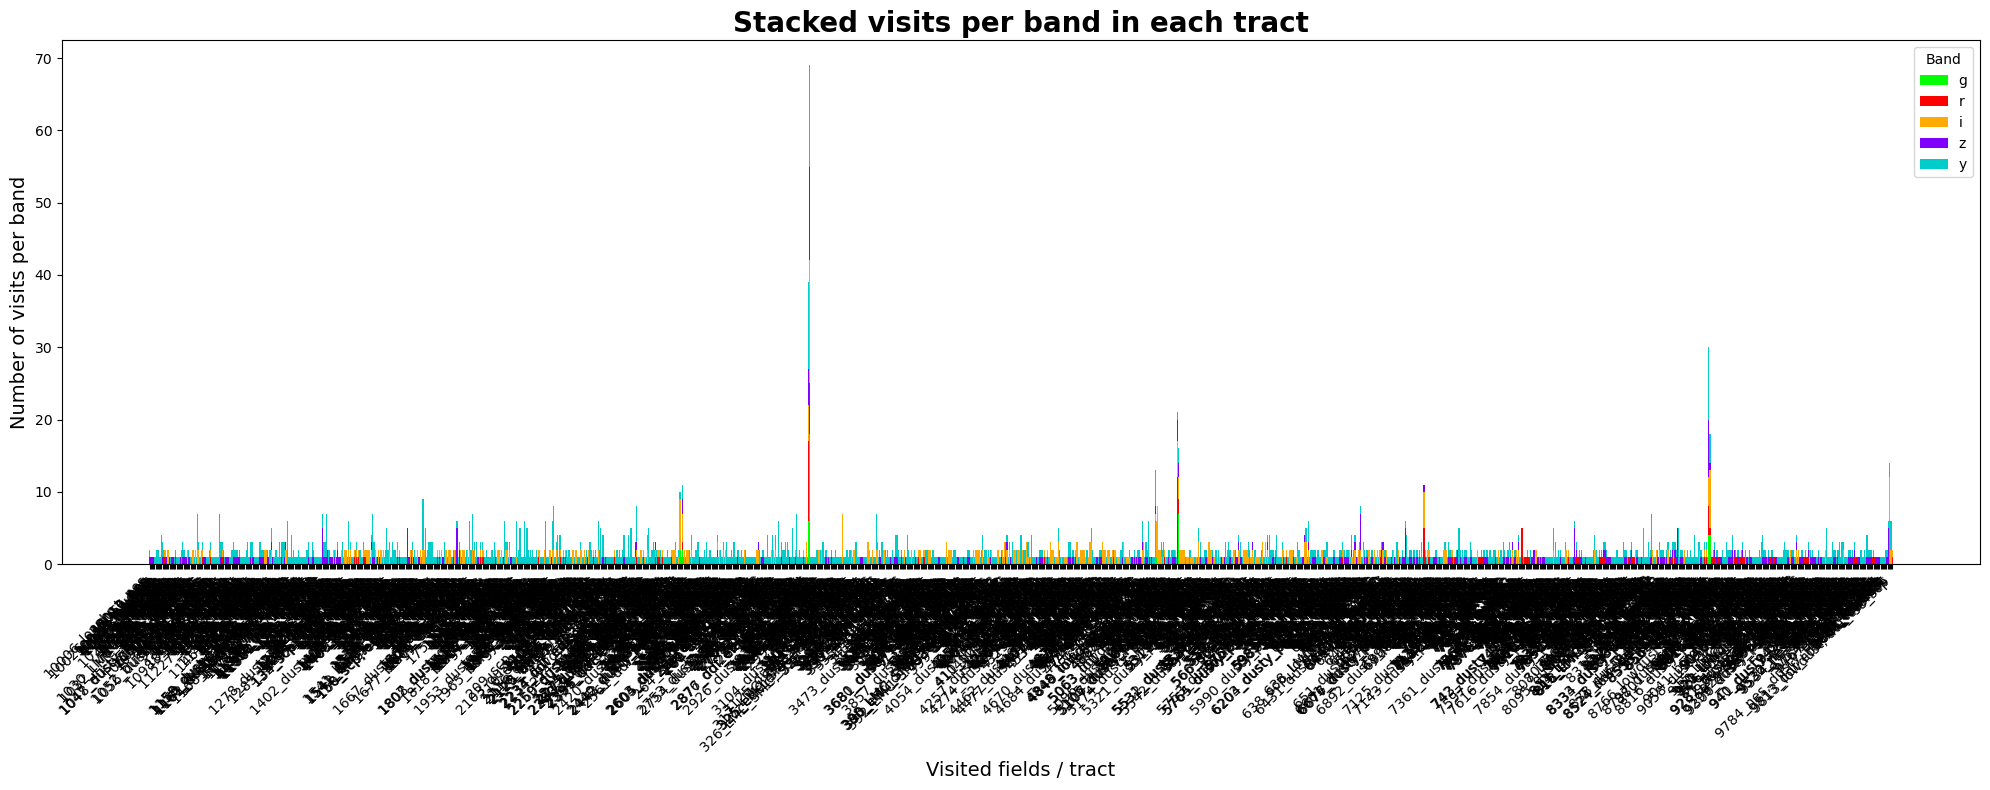

In [28]:
plt.figure(figsize=(20, 8))

bottom = pd.Series([0]*len(df_wide), index=df_wide.index)

for band in band_order:
    plt.bar(
        df_wide.index,
        df_wide[band],
        bottom=bottom,
        color=color_map[band],
        label=band,width=1
    )
    bottom += df_wide[band]

plt.xlabel("Visited fields / tract", fontsize=14)
plt.ylabel("Number of visits per band", fontsize=14)
plt.title("Stacked visits per band in each tract", fontsize=20, fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Band")
plt.tight_layout()
plt.show()

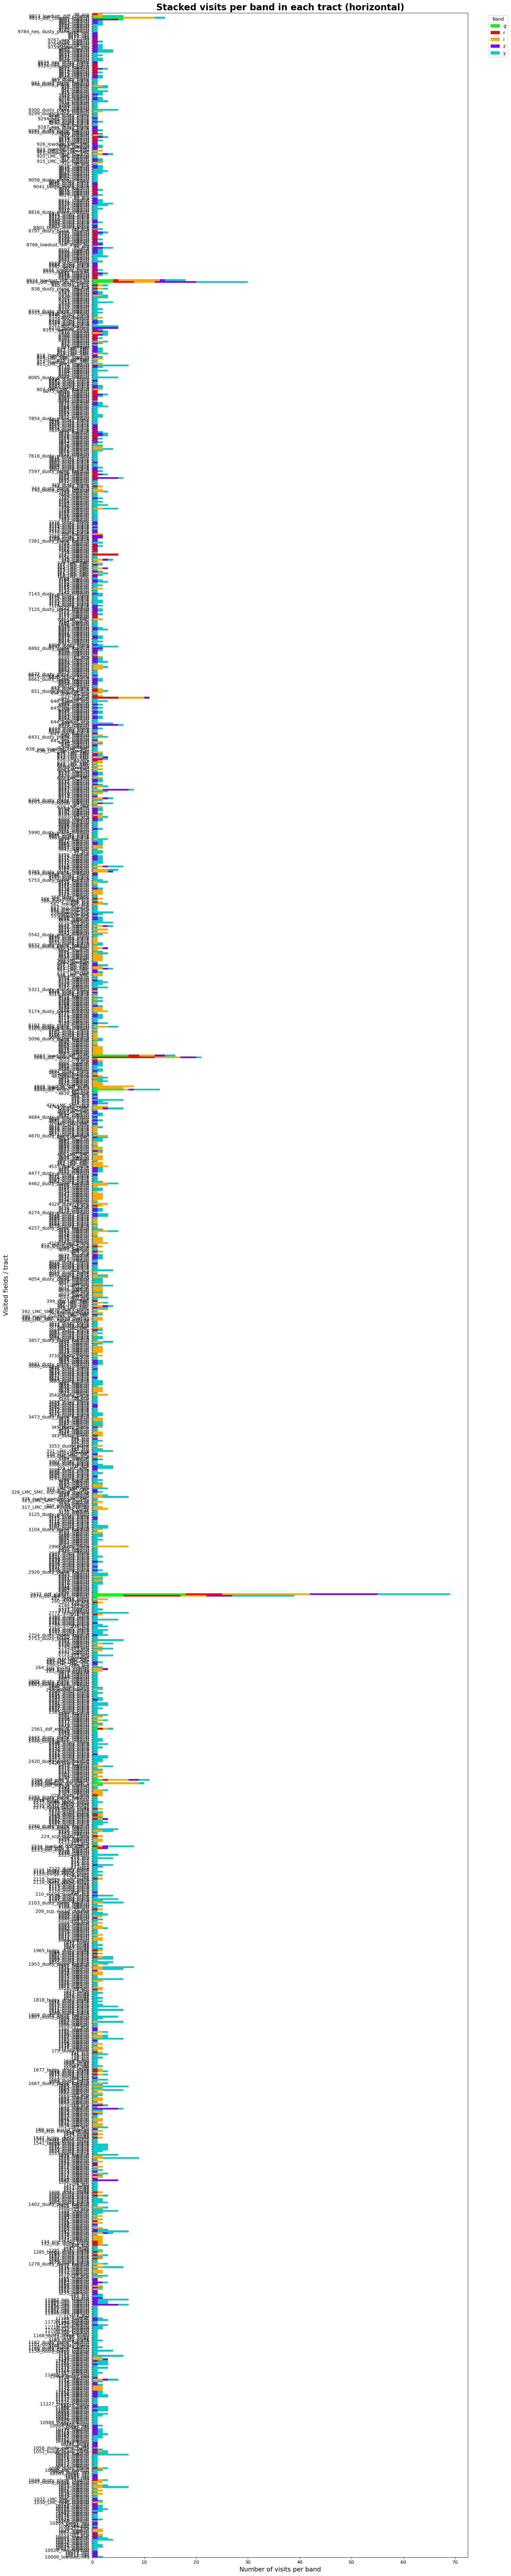

In [29]:

#plt.figure(figsize=(12, max(6, len(df_wide)//2)))  # ajuster la hauteur selon le nombre de tracts
plt.figure(figsize=(16,80))  # ajuster la hauteur selon le nombre de tracts

left = pd.Series([0]*len(df_wide), index=df_wide.index)  # accumulation pour l'empilement

for band in band_order:
    plt.barh(
        y=df_wide.index,
        width=df_wide[band],
        left=left,
        color=color_map[band],
        label=band,
        height=1.0
    )
    left += df_wide[band]

plt.ylabel("Visited fields / tract", fontsize=14)
plt.xlabel("Number of visits per band", fontsize=14)
plt.title("Stacked visits per band in each tract (horizontal)", fontsize=20, fontweight="bold")
plt.legend(title="Band", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(-0.2, len(df_wide)-0.2)
plt.tight_layout()
plt.show()

In [30]:
selected_tags = [
    "2233_ddf_edfs_a, lowdust",
    "2234_ddf_edfs_a, lowdust",
    "2234_lowdust, ddf_edfs_a",
    "2394_ddf_edfs_a, lowdust",
    "2394_lowdust, ddf_edfs_a",
    "2395_ddf_edfs_b, lowdust",
    "2396_ddf_edfs_b, lowdust",
    "2561_ddf_edfs_b, lowdust",
    "2876_ddf_elaiss1, lowdust",
    "2877_ddf_elaiss1, lowdust",
    "4848_ddf_ecdfs, lowdust",
    "4848_lowdust, ddf_ecdfs",
    "4849_lowdust, ddf_ecdfs",
    "5063_ddf_ecdfs, lowdust",
    "5063_lowdust, ddf_ecdfs",
    "8524_ddf_xmm_lss, lowdust",
    "8524_lowdust, ddf_xmm_lss",
    "8766_lowdust, ddf_xmm_lss",
    "9813_ddf_cosmos, lowdust",
    "9813_lowdust, ddf_cosmos"
]

In [31]:
df_subset = grouped_tag[grouped_tag['tag'].isin(selected_tags)]

In [32]:
df_wide = df_subset.pivot(index='tag', columns='band', values='count').fillna(0)
df_wide = df_wide[band_order]  # keep bands in order u→y

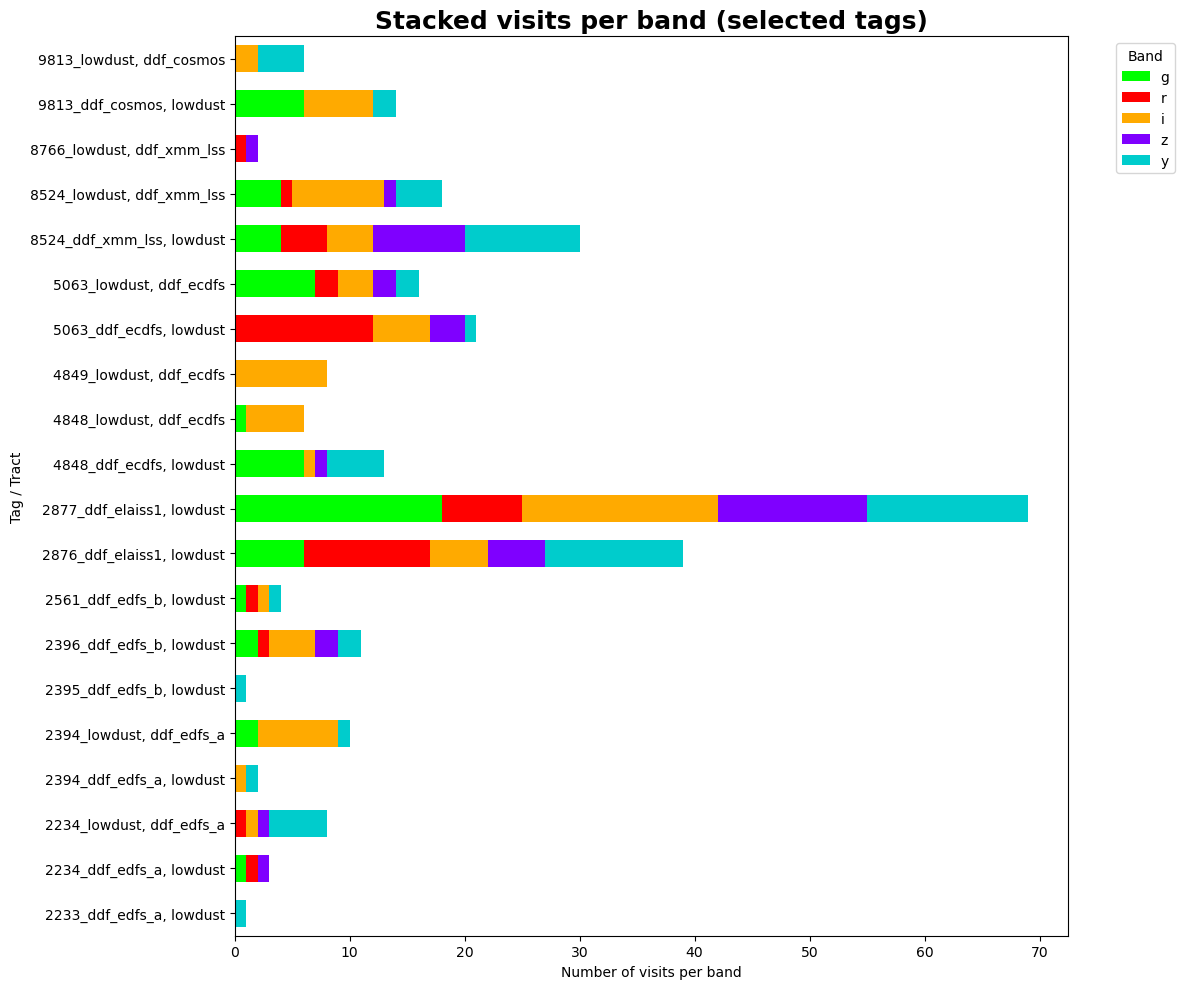

In [33]:
plt.figure(figsize=(12, len(df_wide)*0.5))  # height proportional to number of tags
left = pd.Series([0]*len(df_wide), index=df_wide.index)

for band in band_order:
    plt.barh(
        y=df_wide.index,
        width=df_wide[band],
        left=left,
        color=color_map[band],
        label=band,
        height=0.6
    )
    left += df_wide[band]

plt.xlabel("Number of visits per band")
plt.ylabel("Tag / Tract")
plt.title("Stacked visits per band (selected tags)", fontsize=18, fontweight="bold")
plt.legend(title="Band", bbox_to_anchor=(1.05,1), loc='upper left')

# Remove empty space above/below
plt.ylim(-0.5, len(df_wide)-0.5)

plt.tight_layout()
plt.show()

In [76]:
#butler.registry.queryDatasetTypes()

In [34]:
FLAG_DUMP_DATASETS = True
if FLAG_DUMP_DATASETS:
    for datasetType in registry.queryDatasetTypes():
        if registry.queryDatasets(datasetType, collections=collection).any(
            execute=False, exact=False
        ):
            # Limit search results to the data products
            if (
                ("_config" not in datasetType.name)
                and ("_log" not in datasetType.name)
                and ("_metadata" not in datasetType.name)
                and ("_resource_usage" not in datasetType.name)
                and ("Plot" not in datasetType.name)
                and ("Metric" not in datasetType.name)
                and ("metric" not in datasetType.name)
            ):
                if "object" in datasetType.name or "Obj" in datasetType.name:
                    print(datasetType)
                if "source" in datasetType.name or "Source" in datasetType.name:
                    print(datasetType)
                else:
                    print(datasetType)

DatasetType('skyMap', {skymap}, SkyMap)
DatasetType('the_monster_20250219', {htm7}, SimpleCatalog)
DatasetType('bias', {instrument, detector}, ExposureF, isCalibration=True)
DatasetType('dark', {instrument, detector}, ExposureF, isCalibration=True)
DatasetType('flat', {band, instrument, detector, physical_filter}, ExposureF, isCalibration=True)
DatasetType('linearizer', {instrument, detector}, Linearizer, isCalibration=True)
DatasetType('ptc', {instrument, detector}, PhotonTransferCurveDataset, isCalibration=True)
DatasetType('flat_gradient_reference', {band, instrument, physical_filter}, IsrCalib, isCalibration=True)
DatasetType('bfk', {instrument, detector}, BrighterFatterKernel, isCalibration=True)
DatasetType('cti', {instrument, detector}, IsrCalib, isCalibration=True)
DatasetType('defects', {instrument, detector}, Defects, isCalibration=True)
DatasetType('astrometry_camera', {band, instrument, physical_filter}, Camera, isCalibration=True)
DatasetType('camera', {instrument}, Camera

In [49]:
visits = df_elaiss1["id"].values
visit_list = [int(v) for v in visits]

In [77]:
visit_str = ",".join(str(v) for v in visit_list)

where = f"instrument=\'{instrument}\' AND visit IN ({visit_str})"
refs = list(
    butler.registry.queryDatasets(
        "raw",
        collections=collection,
        where=where
    )
)

In [75]:
len(refs)

21276

In [79]:
print(butler.registry.getDatasetType("dia_source").dimensions)

{skymap, tract}


In [80]:
print(butler.registry.getDatasetType("dia_object").dimensions)

{skymap, tract}
